In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv('data/train.csv')
VOTE_COLS = ['seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']
LABELS = ['seizure', 'lpd', 'gpd', 'lrda', 'grda', 'other']
print(f'Total rows: {len(df):,}  |  Unique patients: {df.patient_id.nunique():,}')

Total rows: 106,800  |  Unique patients: 1,950


## 1. Розподіл класів (dominant vote)

                count   pct
dominant_label             
seizure         20933  19.6
lpd             14856  13.9
gpd             16702  15.6
lrda            16640  15.6
grda            18861  17.7
other           18808  17.6


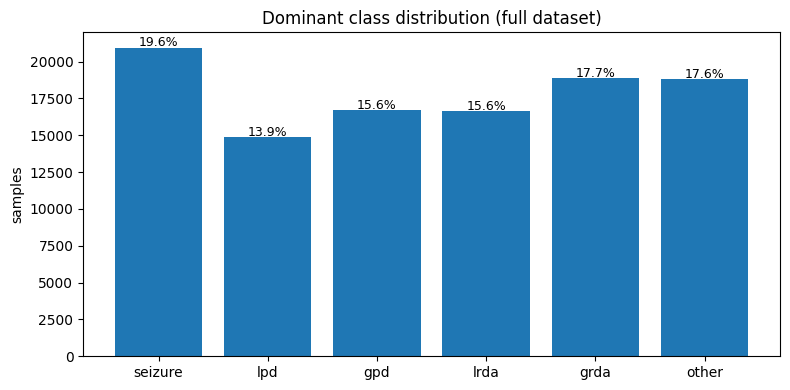

In [2]:
# dominant class = клас з найбільшою кількістю голосів
df['dominant'] = df[VOTE_COLS].values.argmax(axis=1)
df['dominant_label'] = df['dominant'].map(dict(enumerate(LABELS)))

counts = df['dominant_label'].value_counts().reindex(LABELS)
pct = counts / counts.sum() * 100

summary = pd.DataFrame({'count': counts, 'pct': pct.round(1)})
print(summary.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(LABELS, counts.values)
ax.set_title('Dominant class distribution (full dataset)')
ax.set_ylabel('samples')
for i, (c, p) in enumerate(zip(counts.values, pct.values)):
    ax.text(i, c + 100, f'{p:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Розподіл по train/val спліту

In [3]:
# replicating train.py dedup + split logic
spec_df = df.drop_duplicates(subset=['spectrogram_id', 'spectrogram_sub_id']).reset_index(drop=True)
eeg_df  = df.drop_duplicates(subset=['eeg_id', 'eeg_sub_id']).reset_index(drop=True)

def split_counts(data):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, val_idx = next(gss.split(data, groups=data['patient_id']))
    dominant = data[VOTE_COLS].values.argmax(axis=1)
    train_counts = np.bincount(dominant[train_idx], minlength=6)
    val_counts   = np.bincount(dominant[val_idx],   minlength=6)
    return train_counts, val_counts

spec_train, spec_val = split_counts(spec_df)
eeg_train,  eeg_val  = split_counts(eeg_df)

for name, tr, va in [('spec', spec_train, spec_val), ('eeg', eeg_train, eeg_val)]:
    print(f'\n--- {name} ---')
    tbl = pd.DataFrame({'train': tr, 'val': va, 'train_%': (tr/tr.sum()*100).round(1), 'val_%': (va/va.sum()*100).round(1)}, index=LABELS)
    print(tbl.to_string())


--- spec ---
         train   val  train_%  val_%
seizure  16561  4372     19.9   18.7
lpd      11512  3344     13.8   14.3
gpd      11781  4921     14.1   21.1
lrda     13429  3211     16.1   13.7
grda     14812  4049     17.8   17.3
other    15335  3473     18.4   14.9

--- eeg ---
         train   val  train_%  val_%
seizure  16561  4372     19.9   18.7
lpd      11512  3344     13.8   14.3
gpd      11781  4921     14.1   21.1
lrda     13429  3211     16.1   13.7
grda     14812  4049     17.8   17.3
other    15335  3473     18.4   14.9


## 3. Ступінь згоди між лікарями

Total votes per sample:
total_votes
1      4360
2      2316
3     51867
4      3451
5      3974
6       883
7         3
10     1146
11     2602
12     4356
13     7525
14     3887
15    10665
16     5191
17     1445
18     1934
19      250
20      634
21      179
22       54
23       24
24       17
25       20
26        6
27        5
28        6

Max vote share (confidence) by class:
                mean   min   50%  max
dominant_label                       
seizure         0.95  0.20  1.00  1.0
lpd             0.76  0.25  0.79  1.0
gpd             0.73  0.23  0.67  1.0
lrda            0.73  0.25  0.67  1.0
grda            0.86  0.27  1.00  1.0
other           0.81  0.28  0.87  1.0


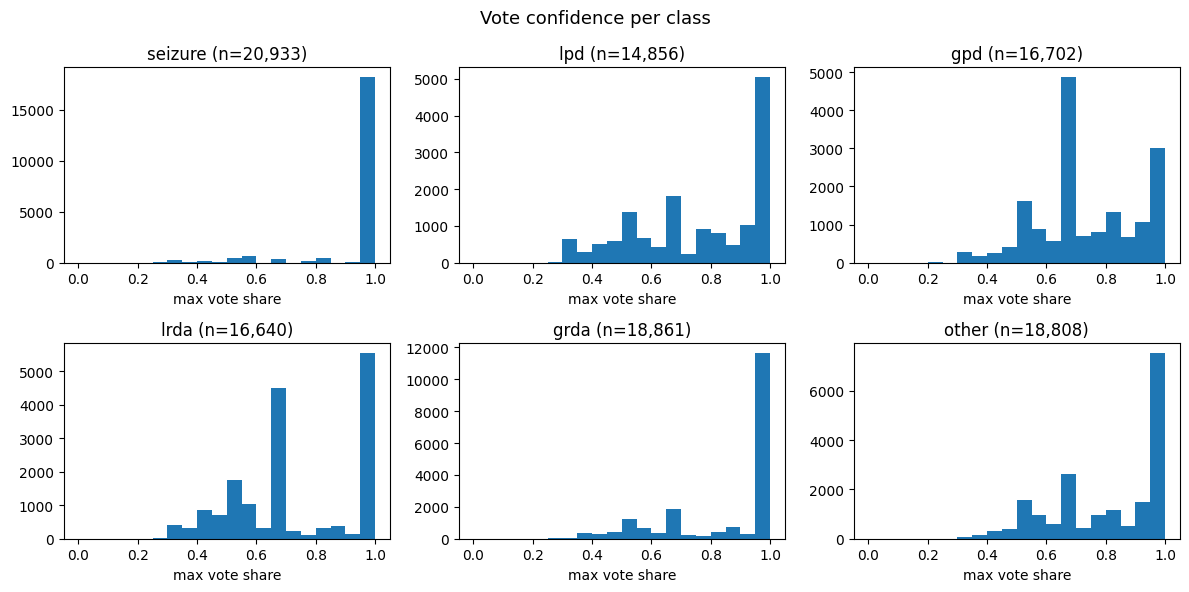

In [4]:
# total votes per sample (кількість лікарів що проголосували)
df['total_votes'] = df[VOTE_COLS].sum(axis=1)
# max vote share = наскільки впевнений домінуючий клас
df['max_share'] = df[VOTE_COLS].max(axis=1) / df['total_votes']

print('Total votes per sample:')
print(df['total_votes'].value_counts().sort_index().to_string())

print('\nMax vote share (confidence) by class:')
print(df.groupby('dominant_label')['max_share'].describe()[['mean','min','50%','max']].round(2).reindex(LABELS).to_string())

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, label in zip(axes.flat, LABELS):
    data = df[df['dominant_label'] == label]['max_share']
    ax.hist(data, bins=20, range=(0, 1))
    ax.set_title(f'{label} (n={len(data):,})')
    ax.set_xlabel('max vote share')
fig.suptitle('Vote confidence per class', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Ваги для WeightedRandomSampler

In [5]:
# скільки б семплів кожного класу з'явилось у збалансованому трейні
for name, tr in [('spec', spec_train), ('eeg', eeg_train)]:
    weights = 1.0 / np.maximum(tr, 1)
    weights /= weights.sum()
    expected = (weights * tr.sum()).round().astype(int)
    print(f'\n{name}: expected samples per class with WeightedRandomSampler')
    print(pd.Series(expected, index=LABELS).to_string())


spec: expected samples per class with WeightedRandomSampler
seizure    11467
lpd        16496
gpd        16120
lrda       14142
grda       12821
other      12384

eeg: expected samples per class with WeightedRandomSampler
seizure    11467
lpd        16496
gpd        16120
lrda       14142
grda       12821
other      12384
